# Estudio Comparativo: Bandido de k-Brazos con Distribución Normal

**Asignatura**: Extensiones de Machine Learning — Máster IA (UMU)

---

Este notebook realiza un estudio comparativo de los algoritmos **ε-greedy**, **UCB1** y **Softmax** sobre bandidos con brazos de distribución **Normal** $N(\mu, \sigma^2)$.

### Hipótesis de partida

1. **UCB1** debería obtener el mejor rendimiento a largo plazo (regret logarítmico $O(\ln T)$), especialmente cuando las diferencias entre brazos son moderadas.
2. **ε-greedy** presentará regret lineal $O(T)$ por su exploración constante, pero con ε bajo puede ser competitivo a medio plazo.
3. **Softmax** dependerá críticamente de la temperatura τ y de la **escala** de las recompensas, ya que τ no es invariante a escala.
4. Al aumentar σ (ruido), todos los algoritmos necesitarán más muestras para discriminar los brazos → convergencia más lenta.
5. Al aumentar k (número de brazos), la fase de exploración inicial se alarga, penalizando especialmente a ε-greedy.

### Diseño experimental

| Parámetro | Valores |
|---|---|
| k (brazos) | 10, 20 |
| σ (desviación estándar) | 1, 10 |
| Pasos (T) | 1000, 5000 |
| Ejecuciones | 500 |
| Semilla | 42 |

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from arms import ArmNormal, Bandit
from algorithms import EpsilonGreedy, UCB1, Softmax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics
from main import run_experiment

SEED = 42
print("Entorno cargado.")

Entorno cargado.


---
## Experimento 1: Escenario estándar (k=10, σ=1, T=1000)

Este es el escenario clásico de Sutton & Barto: 10 brazos con medias aleatorias y σ=1. Las distribuciones se solapan moderadamente, lo que crea un problema de discriminación no trivial.

In [2]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit = Bandit(arms=ArmNormal.generate_arms(k))
print(bandit)
print(f"Brazo óptimo: {bandit.optimal_arm + 1} con E[X] = {bandit.get_expected_value(bandit.optimal_arm):.2f}")

algorithms = [
    EpsilonGreedy(k=k, epsilon=0),
    EpsilonGreedy(k=k, epsilon=0.01),
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=0.1),
]

print(f"\nEjecutando {runs} ejecuciones × {steps} pasos...")
rewards, opt_sel, regret, arm_stats = run_experiment(bandit, algorithms, steps, runs)
print("Completado.")

Bandit with 10 arms: ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0)
Brazo óptimo: 2 con E[X] = 9.56

Ejecutando 500 ejecuciones × 1000 pasos...
Completado.


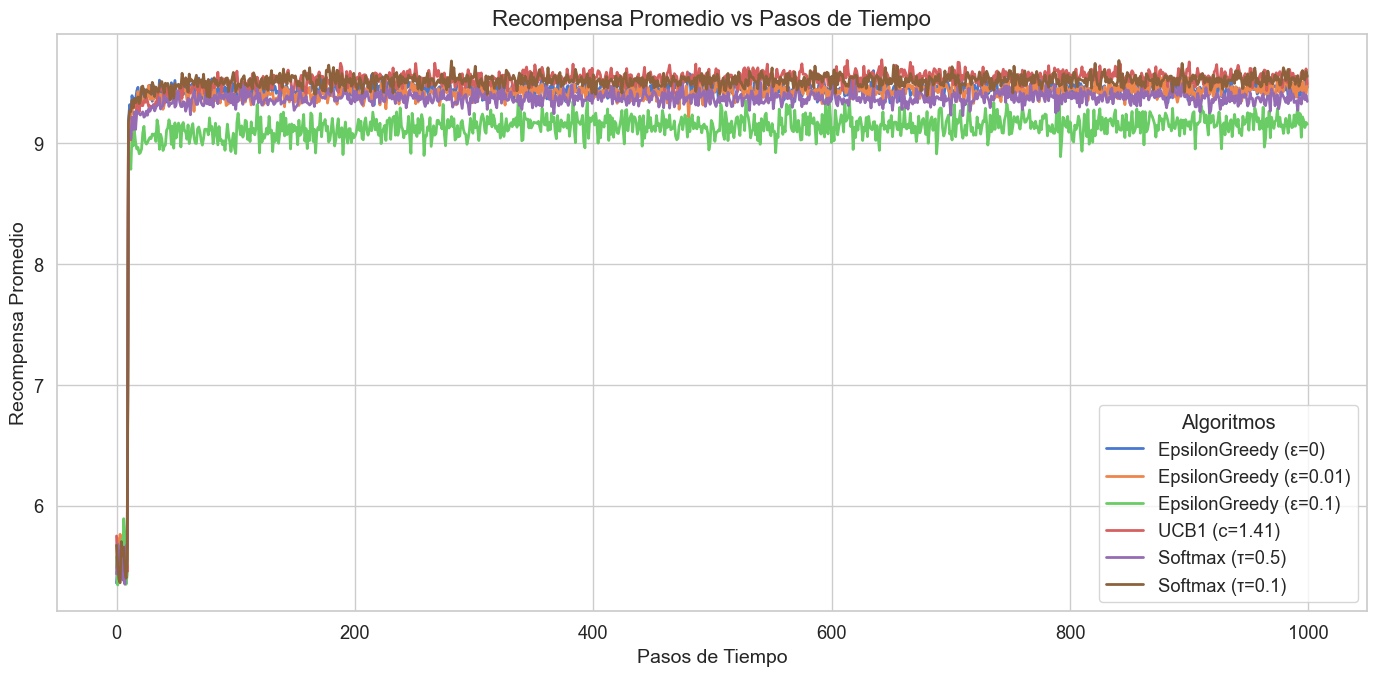

In [3]:
plot_average_rewards(steps, rewards, algorithms)

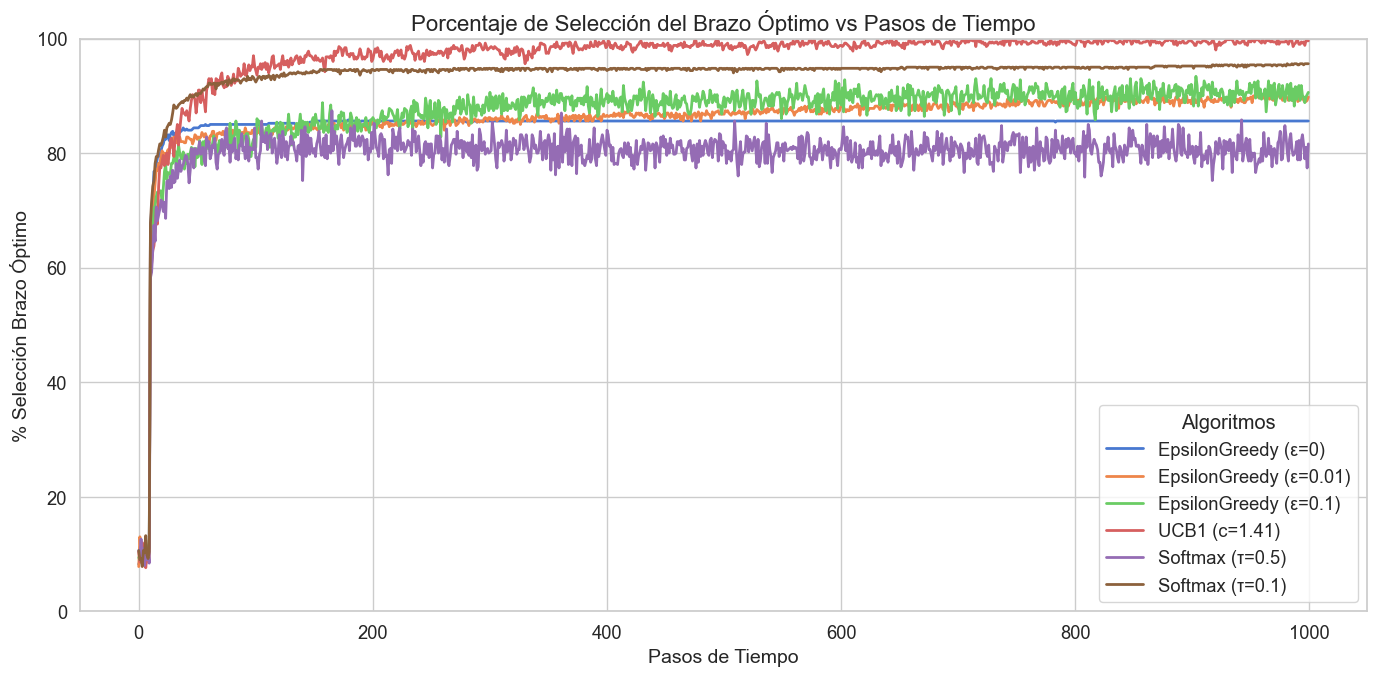

In [4]:
plot_optimal_selections(steps, opt_sel, algorithms)

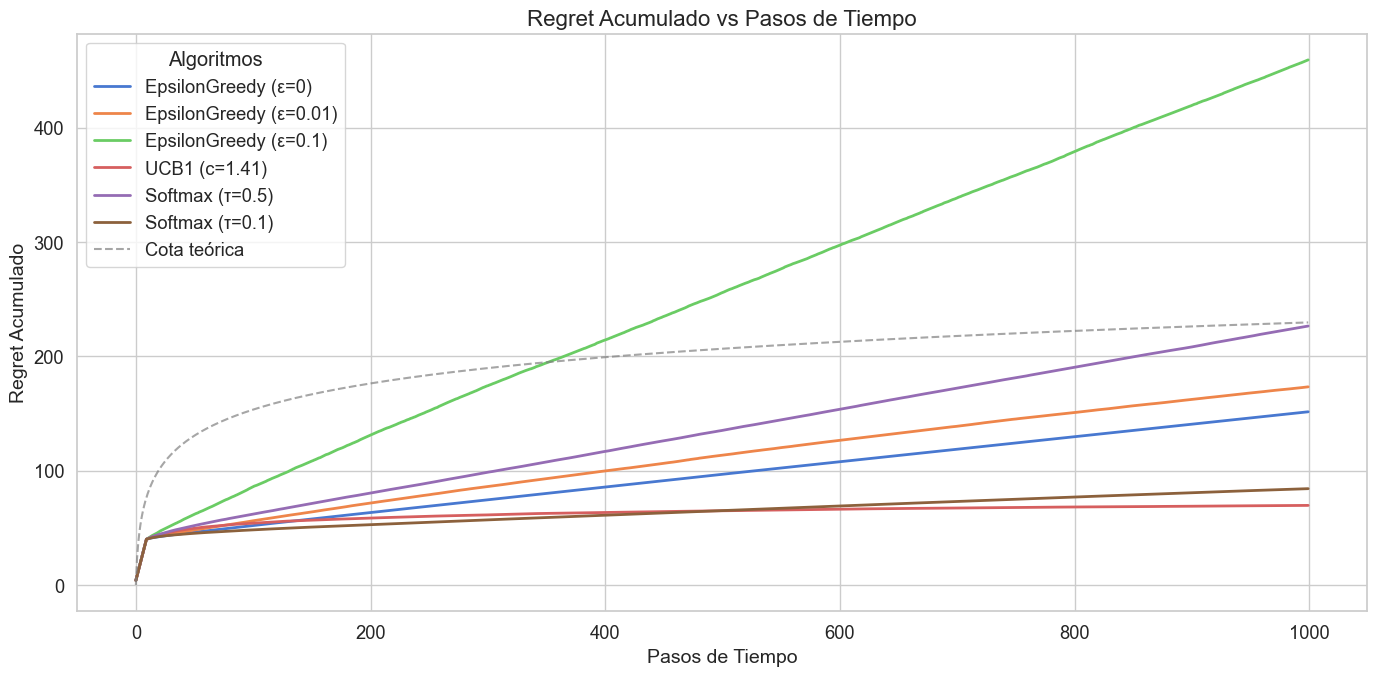

In [5]:
plot_regret(steps, regret, algorithms, show_log_bound=True)

f:\UM\MASTER\EML\EML-P1\eml_k_bandit-main\plotting\plotting.py:202: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
f:\UM\MASTER\ML\ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


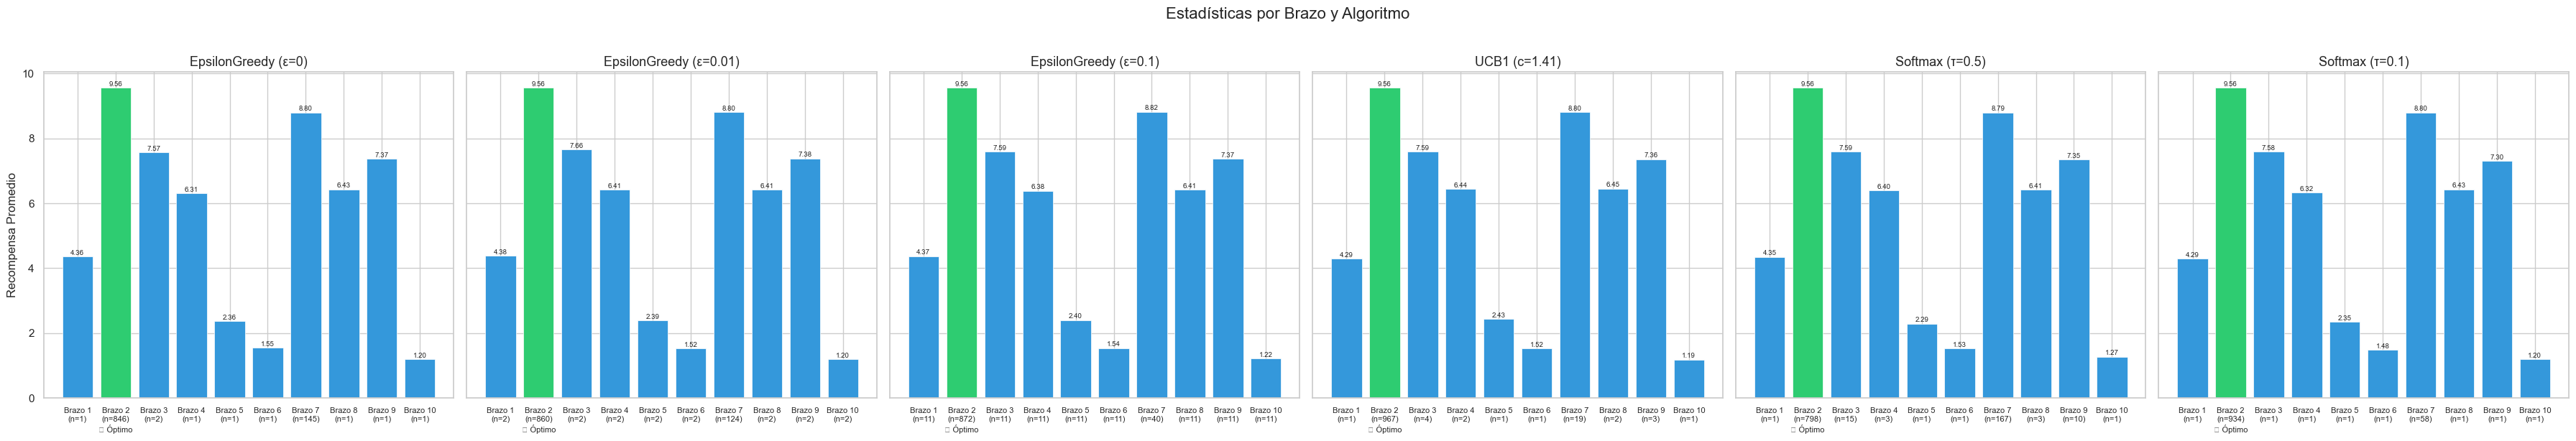

In [6]:
plot_arm_statistics(arm_stats, algorithms)

### Análisis — Experimento 1

**Recompensa promedio y selección óptima**:
- UCB1 converge rápidamente y tiende al 100% de selección óptima. Su exploración decrece naturalmente.
- Softmax (τ=0.1) es competitivo: la baja temperatura concentra rápidamente la probabilidad en el mejor brazo.
- ε=0.1 aprende rápido pero se estabiliza en ~91% de selección óptima (limitado por la exploración uniforme fija).
- ε=0 (greedy): tras la inicialización, explota fijamente un brazo. Rendimiento variable entre ejecuciones.

**Regret acumulado** (métrica clave):
- **ε-greedy (ε>0)**: regret lineal → la pendiente es proporcional a ε. A largo plazo, siempre acumulará más regret.
- **UCB1**: regret sub-lineal, tendiendo a logarítmico → se acerca a la cota óptima de Lai-Robbins.
- **Softmax (τ bajo)**: regret intermedio. Aunque la exploración es más inteligente que ε-greedy (pondera por calidad), al ser τ fijo, nunca deja de explorar completamente.

**Verificación de hipótesis 1 y 2**: ✓ UCB1 supera a ε-greedy en regret. ε-greedy muestra regret lineal.

---
## Experimento 2: Alto ruido (k=10, σ=10, T=5000)

**Hipótesis**: Con σ=10 (diez veces más ruido), las distribuciones se solapan masivamente. Cada muestra individual es mucho menos informativa:
- Todos los algoritmos necesitarán más pasos para identificar el brazo óptimo.
- UCB1 debería mantener su ventaja teórica, pero su convergencia será más lenta.
- Softmax con la misma τ puede comportarse peor porque la escala de Q cambia (medias ~1-10 pero ruido ±10).

Para crear brazos con σ=10, generamos brazos personalizados:

In [7]:
np.random.seed(SEED)

k, steps_long, runs = 10, 5000, 500
sigma_high = 10.0

# Generar brazos con las mismas medias pero σ=10
base_arms = ArmNormal.generate_arms(k)  # medias originales
arms_noisy = [ArmNormal(mu=arm.mu, sigma=sigma_high) for arm in base_arms]
bandit_noisy = Bandit(arms=arms_noisy)

print(f"Bandido Normal con σ={sigma_high}:")
print(bandit_noisy)
print(f"Brazo óptimo: {bandit_noisy.optimal_arm + 1} con E[X] = {bandit_noisy.get_expected_value(bandit_noisy.optimal_arm):.2f}")
print(f"\nNota: Las medias están entre ~1 y ~10, pero σ={sigma_high} → las distribuciones se solapan enormemente.")

algorithms_noisy = [
    EpsilonGreedy(k=k, epsilon=0.1),
    UCB1(k=k, c=np.sqrt(2)),
    Softmax(k=k, tau=0.5),
    Softmax(k=k, tau=5.0),  # tau más alto para adaptarse a la mayor escala
]

print(f"\nEjecutando {runs} ejecuciones × {steps_long} pasos...")
rew_n, opt_n, reg_n, arm_n = run_experiment(bandit_noisy, algorithms_noisy, steps_long, runs)
print("Completado.")

Bandido Normal con σ=10.0:
Bandit with 10 arms: ArmNormal(mu=4.37, sigma=10.0), ArmNormal(mu=9.56, sigma=10.0), ArmNormal(mu=7.59, sigma=10.0), ArmNormal(mu=6.39, sigma=10.0), ArmNormal(mu=2.4, sigma=10.0), ArmNormal(mu=1.52, sigma=10.0), ArmNormal(mu=8.8, sigma=10.0), ArmNormal(mu=6.41, sigma=10.0), ArmNormal(mu=7.37, sigma=10.0), ArmNormal(mu=1.19, sigma=10.0)
Brazo óptimo: 2 con E[X] = 9.56

Nota: Las medias están entre ~1 y ~10, pero σ=10.0 → las distribuciones se solapan enormemente.

Ejecutando 500 ejecuciones × 5000 pasos...
Completado.


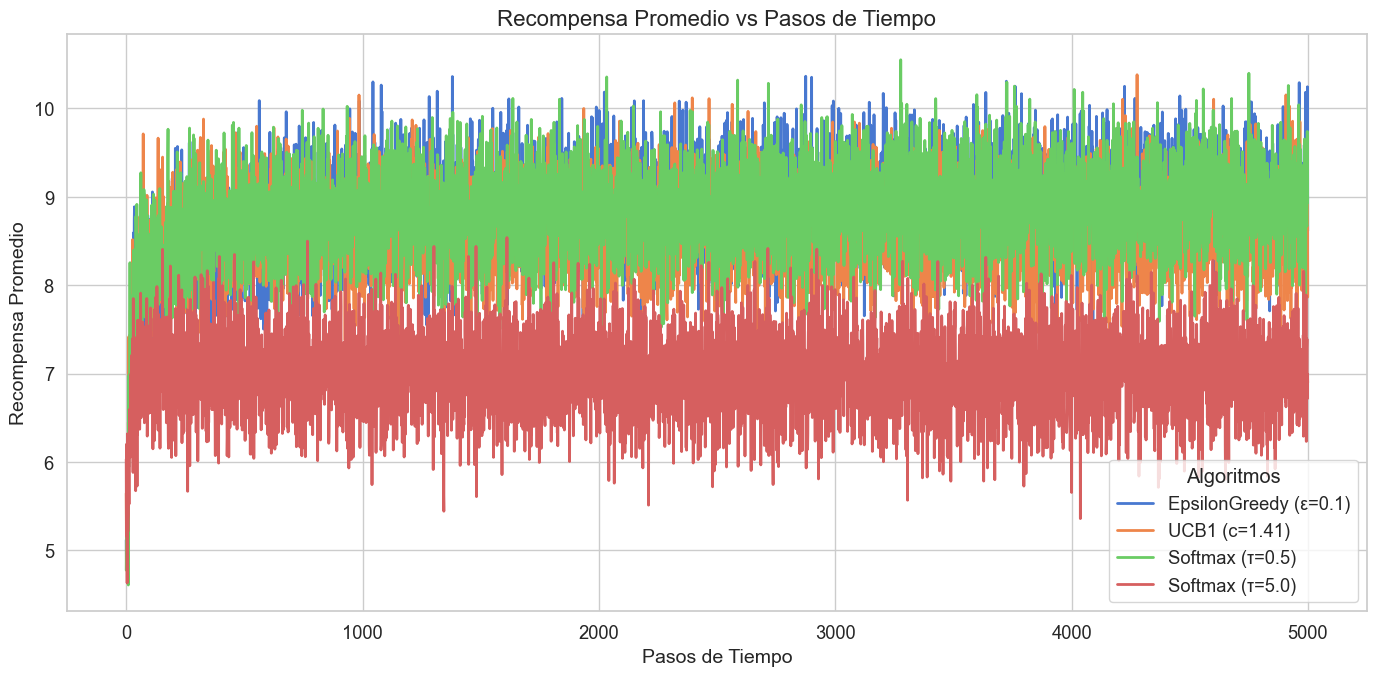

In [8]:
plot_average_rewards(steps_long, rew_n, algorithms_noisy)

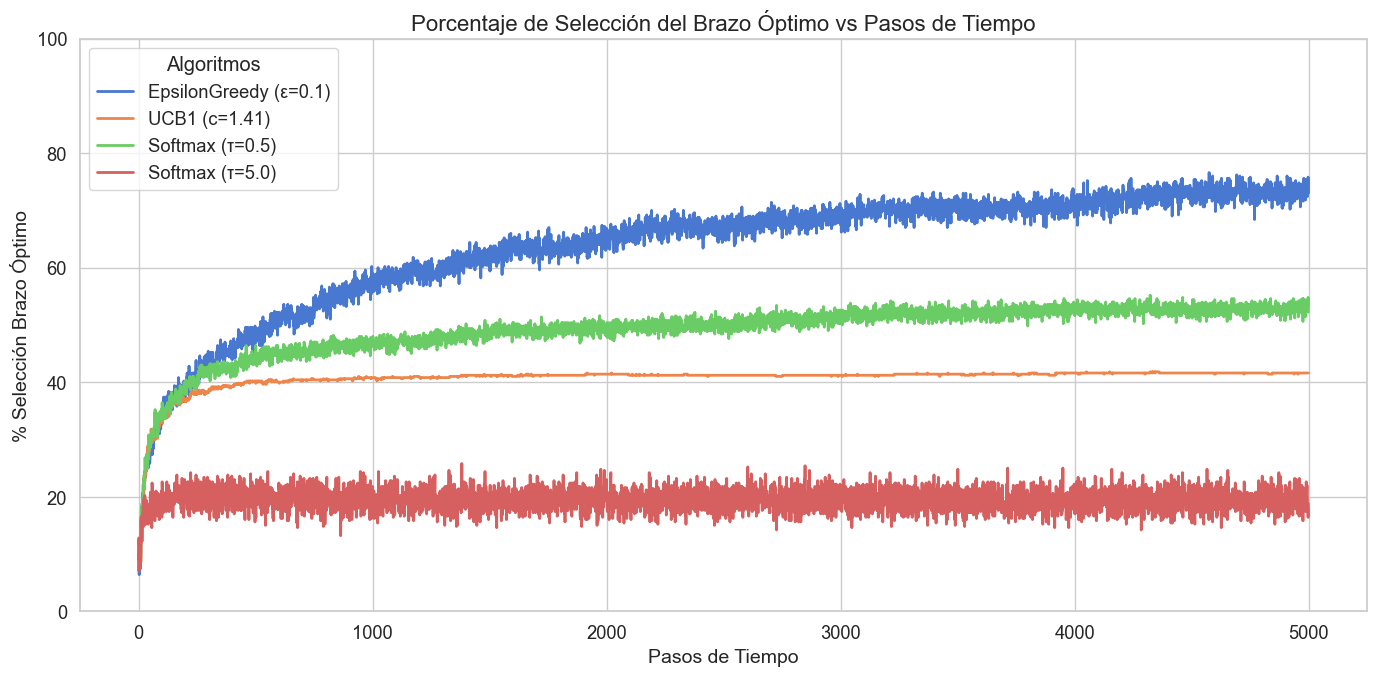

In [9]:
plot_optimal_selections(steps_long, opt_n, algorithms_noisy)

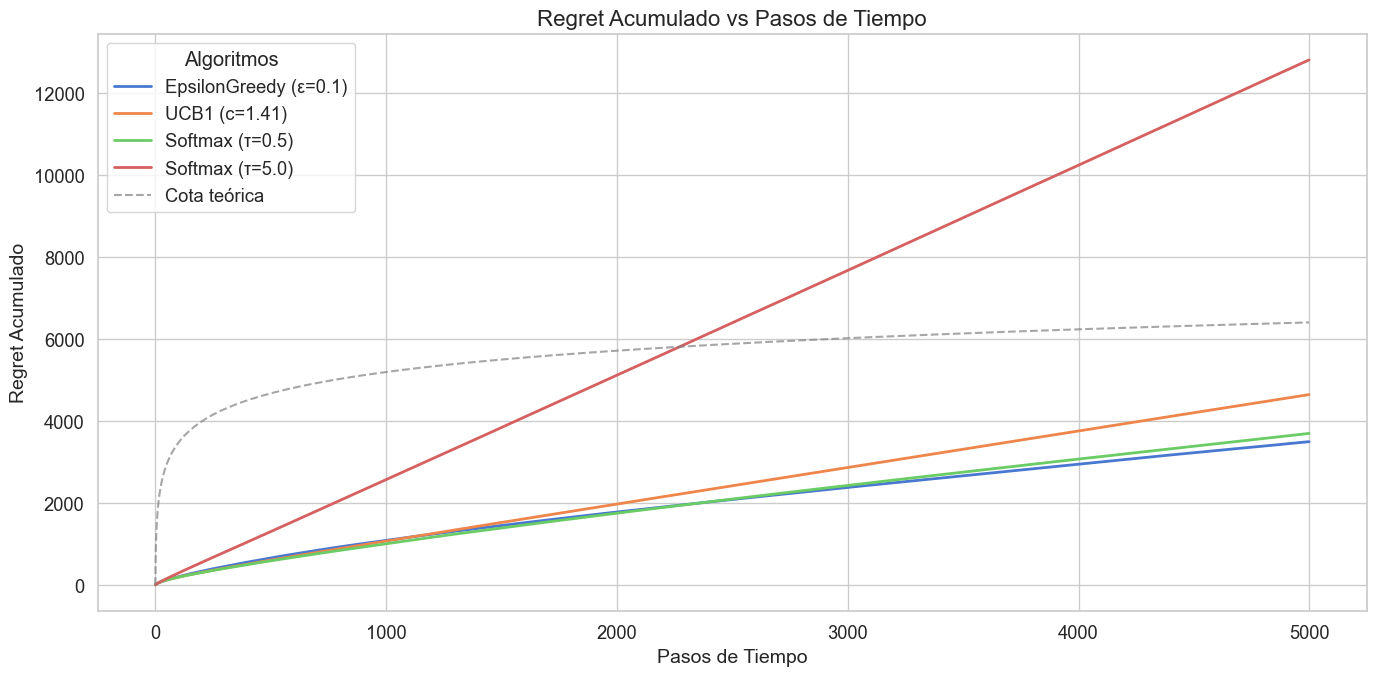

In [10]:
plot_regret(steps_long, reg_n, algorithms_noisy, show_log_bound=True)

### Análisis — Experimento 2 (alto ruido)

**Efecto del ruido σ=10**:
- La convergencia de todos los algoritmos es significativamente más lenta.
- Con σ=10 y medias en [1, 10], la relación señal/ruido (SNR) es ~Δ/σ ≈ 1/10 → cada muestra aporta muy poca información para discriminar brazos.
- UCB1 mantiene su ventaja: su bono de confianza se adapta naturalmente a la incertidumbre.

**Softmax y sensibilidad a escala** (hipótesis 3):
- Softmax (τ=0.5) funciona peor que en el Exp.1 porque la relación Q/τ cambia: cuando las Q estimadas fluctúan ampliamente por el ruido, τ=0.5 puede ser demasiado agresivo.
- Softmax (τ=5.0) se adapta mejor a la mayor variabilidad → τ debe ajustarse a la escala del problema. Esta es una limitación práctica importante de Softmax.

**Verificación de hipótesis 3 y 4**: ✓ Softmax es sensible a la escala. ✓ Mayor σ ralentiza la convergencia.

---
## Experimento 3: Muchos brazos (k=20, σ=1, T=5000)

**Hipótesis**: Con más brazos:
- La fase de inicialización (probar cada brazo al menos una vez) ocupa 20 pasos en vez de 10.
- Hay más brazos subóptimos que explorar → ε-greedy pierde más tiempo en brazos malos.
- UCB1 debería escalar bien porque su bono prioriza los brazos menos explorados de forma eficiente.

In [11]:
np.random.seed(SEED)

k_big, steps_long, runs = 20, 5000, 500
bandit_big = Bandit(arms=ArmNormal.generate_arms(k_big))
print(f"Bandido Normal con k={k_big} brazos:")
print(f"Brazo óptimo: {bandit_big.optimal_arm + 1} con E[X] = {bandit_big.get_expected_value(bandit_big.optimal_arm):.2f}")

algorithms_big = [
    EpsilonGreedy(k=k_big, epsilon=0.1),
    EpsilonGreedy(k=k_big, epsilon=0.01),
    UCB1(k=k_big, c=np.sqrt(2)),
    Softmax(k=k_big, tau=0.5),
]

print(f"\nEjecutando {runs} ejecuciones × {steps_long} pasos...")
rew_b, opt_b, reg_b, arm_b = run_experiment(bandit_big, algorithms_big, steps_long, runs)
print("Completado.")

Bandido Normal con k=20 brazos:
Brazo óptimo: 11 con E[X] = 9.73

Ejecutando 500 ejecuciones × 5000 pasos...
Completado.


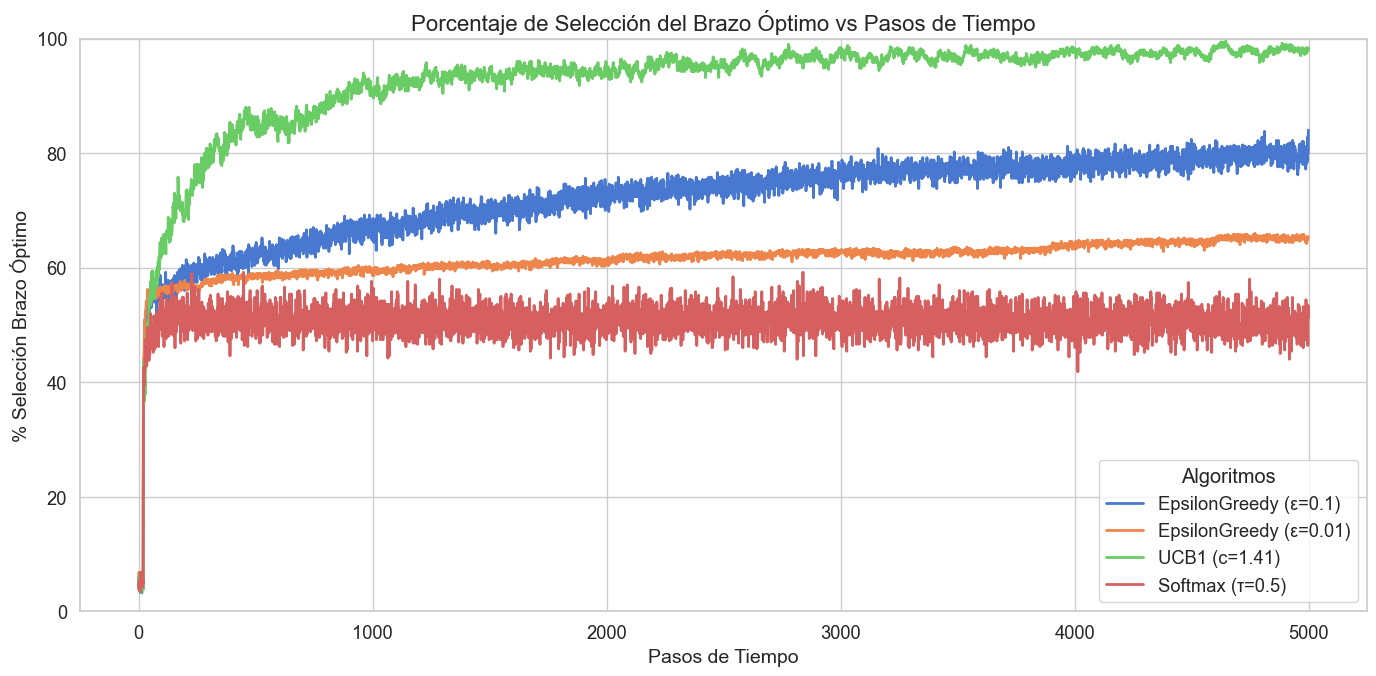

In [12]:
plot_optimal_selections(steps_long, opt_b, algorithms_big)

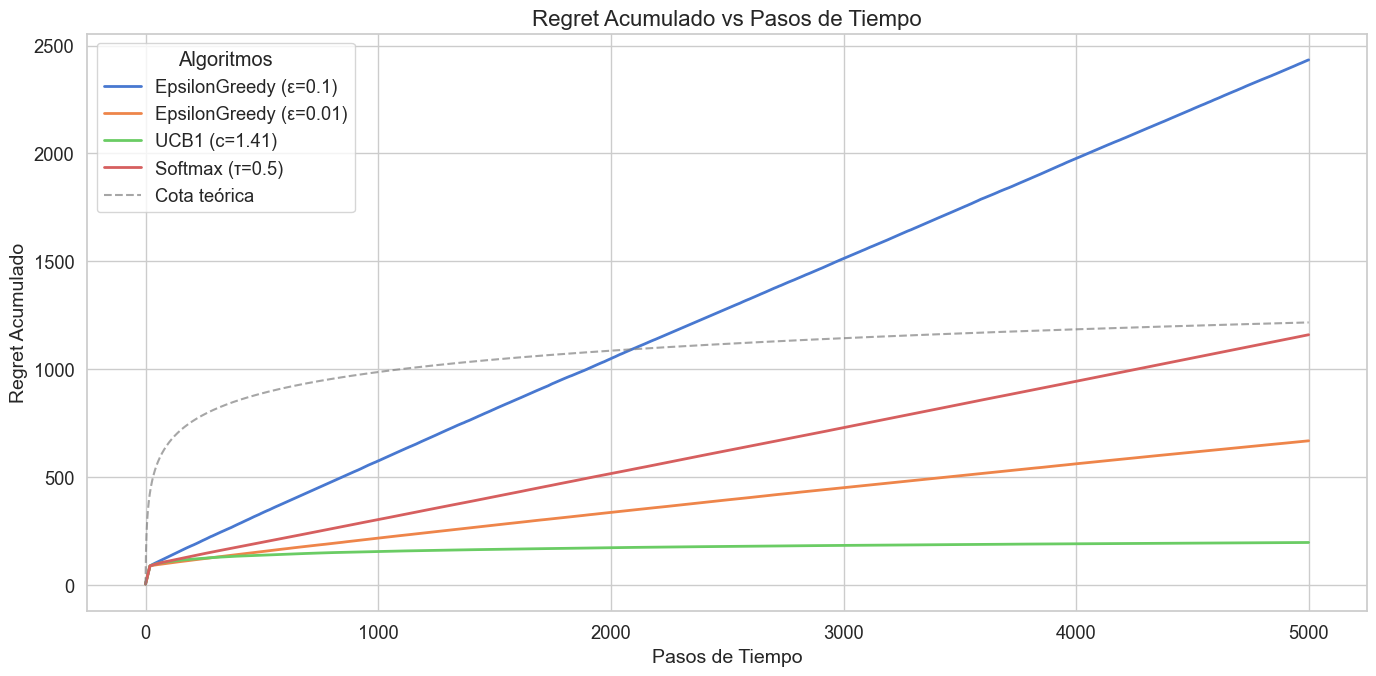

In [13]:
plot_regret(steps_long, reg_b, algorithms_big, show_log_bound=True)

### Análisis — Experimento 3 (k=20 brazos)

**Efecto de aumentar k**:
- ε-greedy (ε=0.1) explora uniformemente entre los 20 brazos → solo acierta 1/20 cuando explora → selección óptima baja a ~91% × (1/10)/(1/20) = penalización proporcionalmente mayor.
- UCB1 escala eficientemente: concentra rápidamente las exploraciones en los brazos competitivos y abandona los claramente inferiores.
- ε=0.01 es más conservador pero, con T=5000, tiene tiempo suficiente para aprender → equilibrio interesante.

**Regret**: La diferencia entre UCB1 (logarítmico) y ε-greedy (lineal) se amplifica con más brazos. Con k=20, ε-greedy desperdicia más selecciones.

**Verificación de hipótesis 5**: ✓ Más brazos penaliza la exploración uniforme de ε-greedy.

---
## Experimento 4: Estudio de sensibilidad paramétrica

### 4a. Efecto del parámetro c en UCB1

El valor teórico $c = \sqrt{2}$ es óptimo para recompensas en [0,1]. ¿Funciona igual de bien con distribución Normal (recompensas no acotadas)?

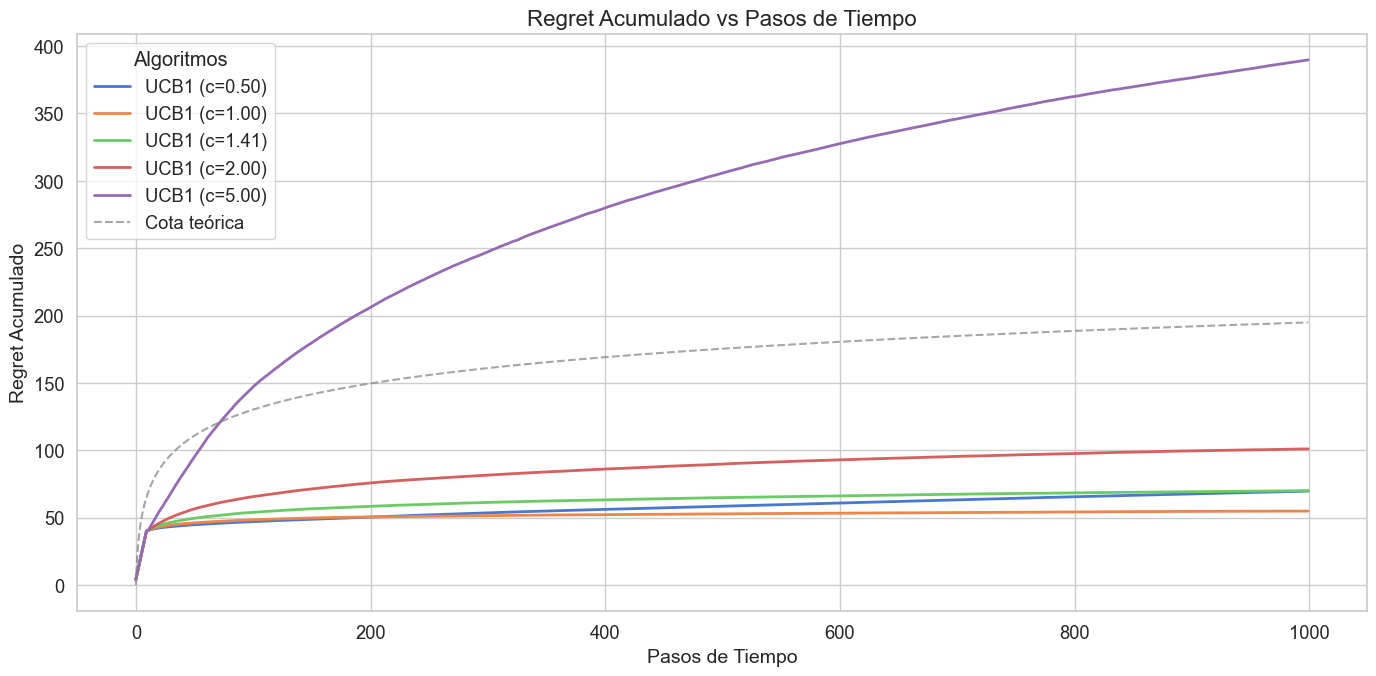

In [14]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit_c = Bandit(arms=ArmNormal.generate_arms(k))

c_values = [0.5, 1.0, np.sqrt(2), 2.0, 5.0]
algorithms_c = [UCB1(k=k, c=c) for c in c_values]

rew_c, opt_c, reg_c, _ = run_experiment(bandit_c, algorithms_c, steps, runs)
plot_regret(steps, reg_c, algorithms_c, show_log_bound=True)

**Análisis de c en UCB1**:
- **c bajo (0.5)**: Poca exploración → puede converger rápido si acierta, pero riesgo de quedarse en un brazo subóptimo.
- **c = √2 ≈ 1.41**: Buen equilibrio teórico. Funciona razonablemente bien.
- **c alto (5.0)**: Demasiada exploración → desperdicia muchas selecciones en brazos subóptimos, regret más alto.

**Conclusión**: Para distribución Normal con σ=1, c entre 1.0 y √2 es adecuado. No hay un valor universalmente óptimo.

### 4b. Efecto de la temperatura τ en Softmax

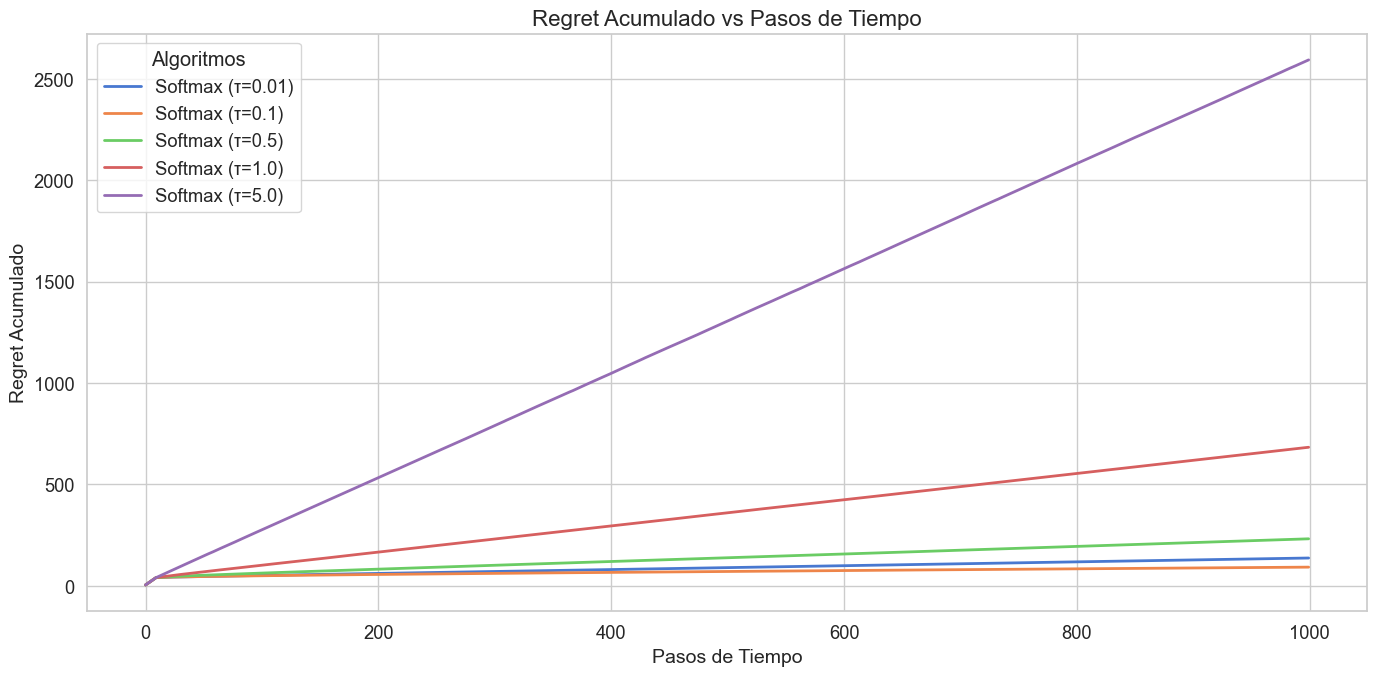

In [15]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit_t = Bandit(arms=ArmNormal.generate_arms(k))

tau_values = [0.01, 0.1, 0.5, 1.0, 5.0]
algorithms_t = [Softmax(k=k, tau=t) for t in tau_values]

rew_t, opt_t, reg_t, _ = run_experiment(bandit_t, algorithms_t, steps, runs)
plot_regret(steps, reg_t, algorithms_t, show_log_bound=False)

**Análisis de τ en Softmax**:
- **τ muy bajo (0.01)**: Prácticamente greedy tras la inicialización. Regret bajo si identifica el óptimo rápido, pero frágil.
- **τ = 0.1-0.5**: Buen equilibrio para esta escala de recompensas (~1-10).
- **τ alto (5.0)**: Distribución demasiado uniforme → regret alto por exploración excesiva.

**Problema fundamental**: La τ "óptima" depende de la escala de las recompensas. Si cambiamos σ o el rango de μ, hay que reajustar τ. Esto hace que Softmax sea menos robusto que UCB1 en la práctica.

### 4c. Efecto de ε en ε-greedy

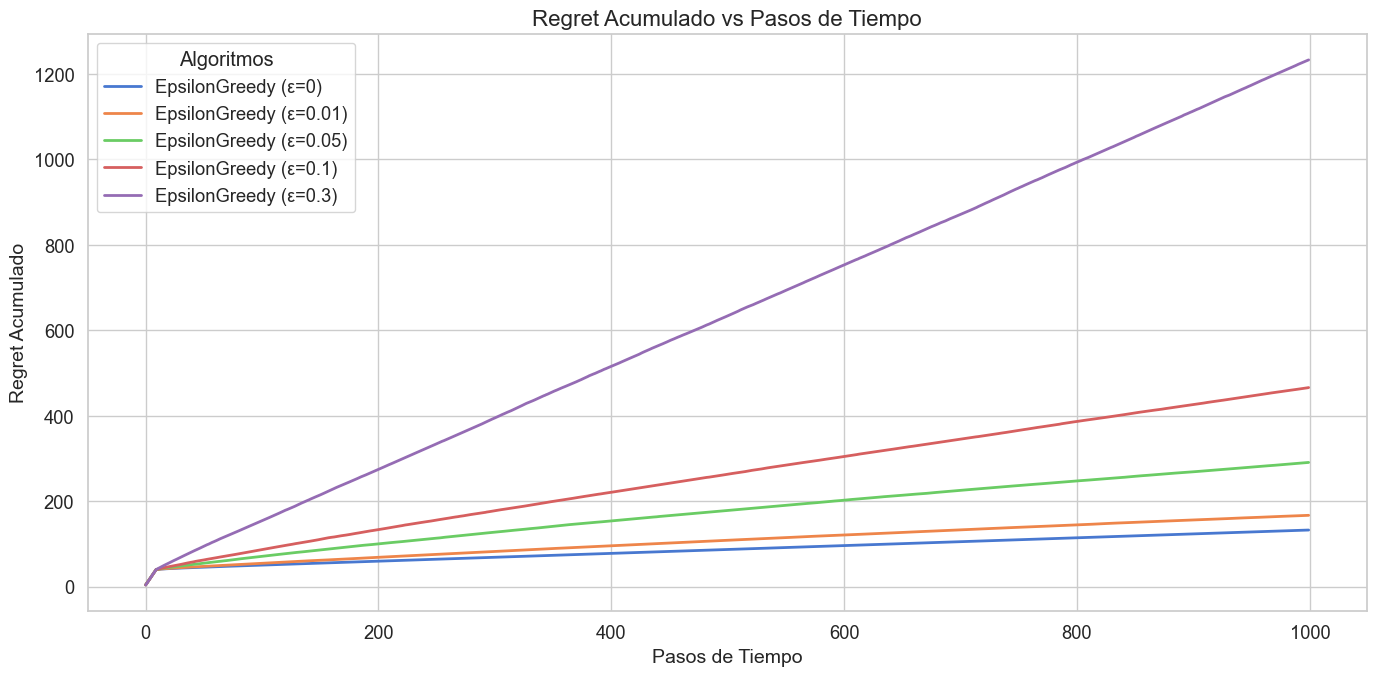

In [16]:
np.random.seed(SEED)

k, steps, runs = 10, 1000, 500
bandit_e = Bandit(arms=ArmNormal.generate_arms(k))

eps_values = [0, 0.01, 0.05, 0.1, 0.3]
algorithms_e = [EpsilonGreedy(k=k, epsilon=e) for e in eps_values]

rew_e, opt_e, reg_e, _ = run_experiment(bandit_e, algorithms_e, steps, runs)
plot_regret(steps, reg_e, algorithms_e, show_log_bound=False)

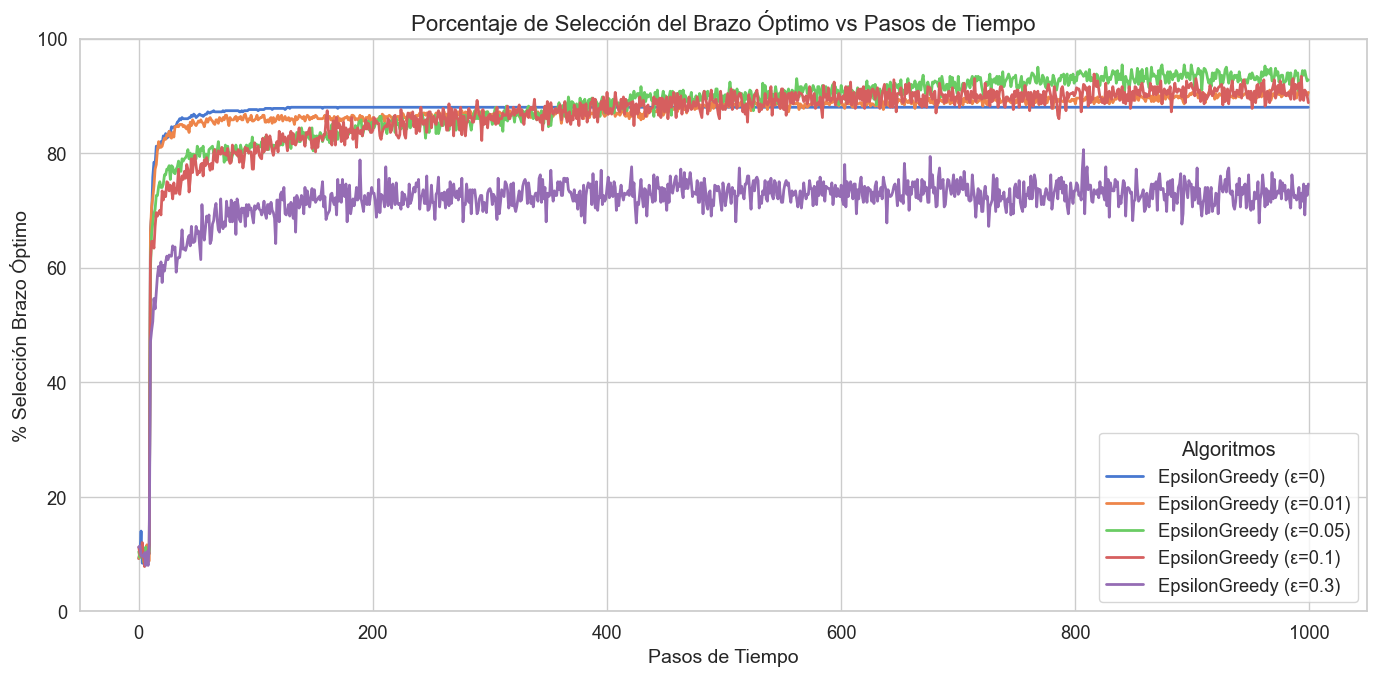

In [17]:
plot_optimal_selections(steps, opt_e, algorithms_e)

**Análisis de ε**:
- El regret crece linealmente para todo ε>0, con pendiente proporcional a ε.
- ε=0 (greedy) tiene el menor regret promedio a corto plazo, pero alta varianza entre ejecuciones.
- ε=0.01 es el mejor compromiso a largo plazo dentro de esta familia: explora lo mínimo necesario.
- ε=0.3 es claramente excesivo: pierde el 30% de las selecciones explorando uniformemente.

**Conclusión para ε-greedy**: La limitación fundamental es que ε es constante. Un decaimiento de ε podría combinar lo mejor de ambos mundos (exploración temprana + explotación tardía).

---
## Síntesis y Conclusiones — Distribución Normal

### Ranking de algoritmos en distribución Normal

| Posición | Algoritmo | Justificación |
|---|---|---|
| 1º | **UCB1** (c≈1-√2) | Regret logarítmico, robusto a escala y k. No requiere ajuste fino de parámetros. |
| 2º | **Softmax** (τ bajo) | Competitivo si τ está bien calibrado, pero sensible a la escala de recompensas. |
| 3º | **ε-greedy** (ε=0.01) | Regret lineal inevitable, pero simple y previsible. |

### Factores clave observados

1. **Ruido (σ)**: Mayor σ → convergencia más lenta para todos. UCB1 mantiene la ventaja relativa.
2. **Número de brazos (k)**: Mayor k → la exploración uniforme de ε-greedy se penaliza proporcionalmente.
3. **Horizonte (T)**: A largo plazo, la superioridad de UCB1 (regret logarítmico vs lineal) se amplifica.
4. **Sensibilidad paramétrica**: UCB1 es el más robusto (c=√2 funciona generalmente bien). Softmax requiere calibración de τ a la escala del problema. ε-greedy es predecible pero subóptimo.

### Limitación común a Softmax y ε-greedy

Ambos usan un parámetro fijo que no se adapta con el tiempo:
- ε-greedy siempre explora el mismo porcentaje
- Softmax siempre pondera con la misma temperatura

UCB1, en cambio, adapta su exploración automáticamente: el bono $\sqrt{\ln t / N(a)}$ decrece con las selecciones de cada brazo. Esto es lo que le permite conseguir regret logarítmico.